# 03 · Avaliação

O enunciado avisa que **não basta a resposta estar bem escrita**: conta recuperar o que é relevante, ficar coerente com as evidências, não inventar e reconhecer quando falta informação. Por isso cada critério esperado vira uma métrica:

| Critério esperado (enunciado) | Como medimos | Fonte |
|---|---|---|
| Recuperar conteúdos relevantes | precisão@8 e MRR com relevância *silver* (regex de tema), por modo de busca | `recuperacao.csv` |
| Construir contexto adequado | acerto dos filtros de metadados; fração das evidências dentro do recorte pedido, com e sem pré-filtro | `filtros.csv`, `efeito_filtros.csv` |
| Gerar respostas coerentes com as evidências / evitar não fundamentadas | citações inválidas, linhas sem citação removidas, respostas descartadas; auditoria humana de fidelidade (afirmação × evidência citada) | `ponta_a_ponta.csv`, `eval/auditoria_fidelidade.csv` |
| Rastreabilidade | % de respostas com ≥ 1 evidência citada (`review_id`) | `ponta_a_ponta.csv` |
| Reconhecer falta de informação | acerto do status por tipo de pergunta (respondível, sem evidência, insuficiente, fora do escopo), em dois critérios: **tolerante** (recusou quando devia) e **estrito** (recusou pelo motivo certo) | `gate.csv`, `ponta_a_ponta.csv` |

**Desenho experimental.** Dois conjuntos de perguntas, disjuntos: **calibração** (20 perguntas, usadas só para escolher os limiares do gate) e **teste** (31 perguntas, usadas só para medir). Perguntas "sem evidência" têm a ausência **verificada por regex na base** antes da avaliação — se o tema existir, a avaliação falha de propósito.

> Os resultados são produzidos por `scripts/04_calibrar_limiares.py` e `scripts/05_avaliar.py`; este notebook só os lê e apresenta.

In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import pandas as pd, matplotlib.pyplot as plt
from voc_rag.config import get_settings, ROOT
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_colwidth", 100)
s = get_settings()
R = ROOT / "eval" / "resultados" / s.model_slug
resumo = json.loads((R / "resumo.json").read_text(encoding="utf-8"))
cal = json.loads(s.thresholds_path.read_text(encoding="utf-8"))
print(json.dumps({k: resumo[k] for k in ["modelo_embeddings", "reranker", "limiares"]} | {"llm": resumo.get("llm")},
                 ensure_ascii=False, indent=2))

{
  "modelo_embeddings": "intfloat/multilingual-e5-base",
  "reranker": "cross-encoder/mmarco-mMiniLMv2-L12-H384-v1",
  "limiares": {
    "escopo": 0.8316,
    "relevancia": 0.053,
    "min_evidencias": 3,
    "min_base_analitico": 30,
    "calibrados": true
  },
  "llm": "gemini:gemini-3.8-flash"
}


## 1. Calibração dos limiares do gate (conjunto de calibração)

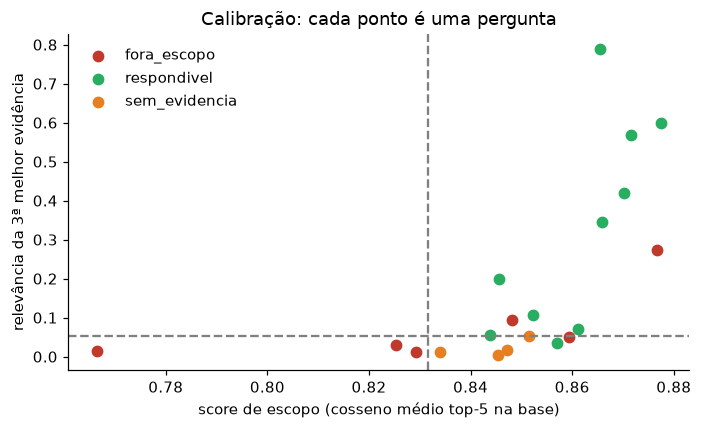

limiar de escopo: 0.8316 | limiar de relevância: 0.053 | acurácia balanceada na calibração: {'escopo': 0.75, 'relevancia': 0.85}


In [2]:
f = pd.DataFrame(cal["features"]); n = cal["min_evidences"]
cores = {"respondivel": "#27ae60", "sem_evidencia": "#e67e22", "fora_escopo": "#c0392b"}
fig, ax = plt.subplots(figsize=(6.5, 4))
for tipo, g in f.groupby("tipo"):
    ax.scatter(g["score_escopo"], g[f"relevancia_top{n}"], label=tipo, color=cores.get(tipo, "gray"), s=45)
ax.axvline(cal["scope_threshold"], ls="--", color="gray"); ax.axhline(cal["relevance_threshold"], ls="--", color="gray")
ax.set_xlabel("score de escopo (cosseno médio top-5 na base)"); ax.set_ylabel(f"relevância da {n}ª melhor evidência")
ax.legend(frameon=False); ax.set_title("Calibração: cada ponto é uma pergunta"); plt.tight_layout(); plt.show()
print("limiar de escopo:", cal["scope_threshold"], "| limiar de relevância:", cal["relevance_threshold"],
      "| acurácia balanceada na calibração:", cal["acuracia_balanceada_calibracao"])

## 2. Recuperação (conjunto de teste)

,modo,precisao@8,rr
0,bm25,0.672,0.938
1,densa,0.797,0.938
2,hibrida,0.875,1.000
3,hibrida+reranker,0.922,1.000


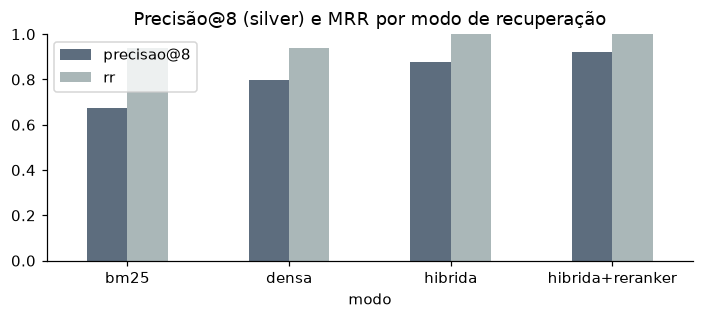

In [3]:
rec = pd.read_csv(R / "recuperacao_resumo.csv")
display(rec)
ax = rec.set_index("modo")[["precisao@8", "rr"]].plot.bar(figsize=(6.5, 3), color=["#5d6d7e", "#aab7b8"])
ax.set_ylim(0, 1); ax.set_title("Precisão@8 (silver) e MRR por modo de recuperação"); ax.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

In [4]:
det = pd.read_csv(R / "recuperacao.csv").pivot(index="id", columns="modo", values="precisao@8")
det

modo,bm25,densa,hibrida,hibrida+reranker
id,,,,
T05,0.625,0.750,0.750,1.000
T08,0.875,1.000,1.000,1.000
T09,0.125,0.625,1.000,0.875
T10,1.000,1.000,1.000,1.000
T11,0.875,1.000,1.000,1.000
T12,0.375,1.000,0.875,1.000
T13,0.875,0.750,0.875,1.000
T14,0.625,0.250,0.500,0.500


> **Limitação da métrica.** A relevância *silver* é uma regex do tema: favorece casamento léxico (BM25) e não reconhece paráfrases fora da lista. Em 7 das 8 perguntas, a regex casa termos da própria pergunta, o que favorece o BM25 e a busca híbrida. Leia os números como comparação indicativa entre modos, não como precisão absoluta.


## 3. Filtros de metadados inferidos da pergunta

In [5]:
pd.read_csv(R / "filtros.csv")

,id,pergunta,esperado,obtido,acerto
0,T04,Quais padrões podem ser identificados nas avaliações de clientes insatisfeitos?,{'nota_max': 2},{'nota_max': 2},True
1,T06,Quais são os principais problemas relatados nas avaliações com nota baixa?,{'nota_max': 2},{'nota_max': 2},True
2,T07,O que os clientes mais elogiam em produtos de beleza e saúde?,{'categorias': ['beleza_saude']},{'categorias': ['beleza_saude']},True
3,T15,Quais problemas aparecem nas avaliações negativas de móveis em 2018?,"{'nota_max': 2, 'data_inicio': '2018-01-01', 'data_fim': '2019-01-01', 'categorias': ['moveis_co...","{'nota_max': 2, 'data_inicio': '2018-01-01', 'data_fim': '2019-01-01', 'categorias': ['moveis_co...",True
4,T16,O que dizem os clientes de SP sobre pedidos entregues com atraso?,"{'ufs': ['SP'], 'situacao_entrega': ['atrasada']}","{'ufs': ['SP'], 'situacao_entrega': ['atrasada']}",True


### Efeito do pré-filtro de metadados (desafio adicional)
A busca semântica só enxerga o texto da avaliação; nota, data, categoria, UF e situação da entrega não estão nele. A tabela mede, para cada pergunta com filtro, a fração das 8 evidências que pertencem ao recorte pedido **com** o pré-filtro do sistema e **sem** ele (mesma pergunta, busca na base inteira).


In [6]:
p = R / "efeito_filtros.csv"
if p.exists():
    ef = pd.read_csv(p)
    display(ef.pivot(index=["id", "filtros"], columns="modo", values="dentro_do_recorte@8").reset_index())
    print(ef.groupby("modo")["dentro_do_recorte@8"].mean().round(3).to_dict())
else:
    print("Rode scripts/05_avaliar.py para gerar efeito_filtros.csv.")

modo,id,filtros,com filtro,sem filtro
0,T04,nota 1–2,1.0,0.500
1,T06,nota 1–2,1.0,0.500
2,T07,categoria ∈ {beleza_saude},1.0,0.125
3,T15,nota 1–2; compra de 2018-01-01 até 2019-01-01 (exclusivo); categoria ∈ {moveis_colchao_e_estofad...,1.0,0.125
4,T16,UF ∈ {SP}; entrega ∈ {atrasada},1.0,0.000


{'com filtro': 1.0, 'sem filtro': 0.25}


## 4. Abstenção: o gate acerta o tipo de pergunta? (teste)

In [7]:
gate = pd.read_csv(R / "gate.csv")
display(gate.groupby("tipo").agg(perguntas=("acerto", "count"), acerto_tolerante=("acerto", "mean"),
                                 acerto_estrito=("acerto_estrito", "mean")).round(3))
print(f"geral: tolerante {gate.acerto.mean():.1%} | estrito {gate.acerto_estrito.mean():.1%}")
pd.crosstab(gate["tipo"], gate["status_gate"])

,perguntas,acerto_tolerante,acerto_estrito
tipo,,,
fora_escopo,6,0.833,0.500
insuficiente,4,0.750,0.500
respondivel,16,0.875,0.875
sem_evidencia,5,1.000,0.800


geral: tolerante 87.1% | estrito 74.2%


status_gate,evidencias_insuficientes,fora_do_escopo,ok,sem_evidencias
tipo,,,,
fora_escopo,1,3,0,2
insuficiente,2,0,1,1
respondivel,0,0,14,2
sem_evidencia,0,1,0,4


In [8]:
gate[~gate["acerto_estrito"]][["id", "tipo", "status_gate", "acerto", "score_escopo", "n_relevantes", "pergunta"]].rename(
    columns={"acerto": "aceito_no_tolerante"})

,id,tipo,status_gate,aceito_no_tolerante,score_escopo,n_relevantes,pergunta
4,T05,respondivel,sem_evidencias,False,0.8621,0,Quais avaliações sustentam a conclusão de que existem problemas recorrentes relacionados ao praz...
6,T07,respondivel,sem_evidencias,False,0.8650,0,O que os clientes mais elogiam em produtos de beleza e saúde?
16,T17,sem_evidencia,fora_do_escopo,True,0.8306,0,O que os clientes acham de pagar com Pix?
22,T23,insuficiente,sem_evidencias,True,0.8523,0,Como foi o atendimento pelo WhatsApp segundo os clientes?
24,T25,insuficiente,ok,False,0.8387,9,Que problemas os clientes tiveram com geladeiras compradas?
26,T27,fora_escopo,sem_evidencias,True,0.8426,0,Qual será a taxa Selic no fim do ano que vem?
27,T28,fora_escopo,sem_evidencias,True,0.8463,0,Escreva um poema sobre o pôr do sol na praia.
29,T30,fora_escopo,evidencias_insuficientes,False,0.8616,1,Como faço para trocar o óleo do motor do meu carro?


## 5. Ponta a ponta (com o LLM)

In [9]:
p = R / "ponta_a_ponta.csv"
if p.exists():
    e2e = pd.read_csv(p)
    ok = e2e[e2e.status == "ok"]
    resumo_e2e = pd.Series({
        "acerto de status (geral)": round(e2e.acerto_status.mean(), 3),
        "acerto estrito (geral)": round(e2e.acerto_estrito.mean(), 3),
        "respostas com status ok": len(ok),
        "respostas ok com ≥1 evidência citada": f"{(ok.n_citadas > 0).mean():.0%}" if len(ok) else "-",
        "citações inválidas (total)": int(e2e.citacoes_invalidas.sum()),
        "linhas sem citação removidas (total)": int(e2e.linhas_sem_citacao_removidas.sum()),
        "recusas do próprio LLM": int(e2e.llm_recusou.sum()),
        "tempo mediano por pergunta (s)": round(e2e.tempo_total_ms.median() / 1000, 1) if e2e.tempo_total_ms.notna().any() else None,
    })
    display(resumo_e2e.to_frame("valor"))
    display(e2e.groupby("tipo").agg(acerto_tolerante=("acerto_status", "mean"), acerto_estrito=("acerto_estrito", "mean")).round(3))
    display(e2e)
else:
    print("Avaliação ponta a ponta ainda não executada (rode scripts/05_avaliar.py sem --sem-llm).")

,valor
acerto de status (geral),0.968
acerto estrito (geral),0.806
respostas com status ok,16
respostas ok com ≥1 evidência citada,100%
citações inválidas (total),0
linhas sem citação removidas (total),0
recusas do próprio LLM,1
tempo mediano por pergunta (s),2.5


,acerto_tolerante,acerto_estrito
tipo,,
fora_escopo,0.833,0.5
insuficiente,1.000,0.5
respondivel,1.000,1.0
sem_evidencia,1.000,0.8


,id,tipo,modo,status,acerto_status,acerto_estrito,n_evidencias,n_citadas,citacoes_invalidas,linhas_sem_citacao_removidas,expressoes_quantitativas,llm_recusou,tempo_total_ms
0,T01,respondivel,analitico,ok,True,True,10,10,0,0,0,False,6850.9
1,T02,respondivel,rag,ok,True,True,7,5,0,0,0,False,2573.0
2,T03,respondivel,analitico,ok,True,True,10,10,0,0,0,False,4435.6
3,T04,respondivel,analitico,ok,True,True,10,10,0,0,0,False,5074.5
4,T05,respondivel,analitico,ok,True,True,8,7,0,0,0,False,4390.3
5,T06,respondivel,analitico,ok,True,True,10,10,0,0,0,False,5095.6
6,T07,respondivel,analitico,ok,True,True,10,10,0,0,0,False,4744.3
7,T08,respondivel,rag,ok,True,True,7,7,0,0,0,False,2950.0
8,T09,respondivel,rag,ok,True,True,8,8,0,0,0,False,2440.4
9,T10,respondivel,rag,ok,True,True,8,8,0,0,0,False,3106.6


### Auditoria humana de fidelidade
A verificação automática confere se cada citação `[E#]` existe; não confere se a evidência **sustenta** a frase. Para medir isso, cada frase das respostas geradas foi anotada por uma pessoa em `eval/auditoria_fidelidade.csv` (`sustentada`: 1 = a evidência citada sustenta a frase; 0 = não sustenta; P = sustenta em parte).


In [10]:
p = ROOT / "eval" / "auditoria_fidelidade.csv"
if p.exists():
    from voc_rag.evaluation import read_annotation_csv
    fid = read_annotation_csv(p)
    a = fid[fid["sustentada"].str.strip().str.upper().isin(["1", "0", "P"])].copy()
    if len(a):
        a["sustentada"] = a["sustentada"].str.strip().str.upper()
        print("anotador:", ", ".join(sorted(set(a["anotador"]) - {""})) or "não informado", f"| frases anotadas: {len(a)} de {len(fid)}")
        display(a["sustentada"].value_counts(normalize=True).rename({"1": "sustentada", "P": "em parte", "0": "não sustentada"}).round(3).to_frame("fração"))
        display(a.groupby("modo")["sustentada"].value_counts(normalize=True).unstack(fill_value=0).round(3))
        display(a[a["sustentada"] != "1"][["id", "frase", "citacoes", "sustentada", "observacao"]])
    else:
        print(f"Auditoria ainda não anotada: preencha a coluna 'sustentada' em {p.name}.")
else:
    print("Planilha não gerada: rode python scripts/08_preparar_auditoria_fidelidade.py")

anotador: Gustavo | frases anotadas: 72 de 72


,fração
sustentada,
sustentada,0.958
em parte,0.042


sustentada,1,P
modo,,
analitico,0.931,0.069
rag,0.977,0.023


,id,frase,citacoes,sustentada,observacao
11,T03,"Boa qualidade do produto (3917 avaliações, 14,1%): Os relatos apontam que os produtos têm excele...",E5 E6,P,O adjetivo 'excelente' não consta nas evidências citadas E5 e E6 (citam apenas 'qualidade' e 'bo...
15,T04,"Não recomenda / insatisfação geral (1543 avaliações, 14,2%): Clientes expressam que não recomend...",E3 E4,P,"A avaliação E3 afirma explicitamente 'Loja recomendada', contradizendo a afirmação de que não re..."
58,T13,Mesma loja e insatisfação: Apontamento de que a entrega veio incompleta mesmo se tratando de pro...,E3 E5,P,Junta duas avaliações distintas estabelecendo relação causal inexistente: E3 cita 'mesma loja' s...


## 6. Comparação de modelos de embedding (opcional)

In [11]:
p = ROOT / "eval" / "resultados" / "comparacao_embeddings.csv"
if p.exists():
    comp = pd.read_csv(p); display(comp)
else:
    print("Comparação não executada (scripts/07_comparar_embeddings.py).")

,modelo,dimensao,segundos_indexacao,modo,precisao@8,mrr
0,tfidf+svd(256),256,32.1,densa,0.625,0.750
1,tfidf+svd(256),256,32.1,hibrida,0.750,0.875
2,sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2,384,528.9,densa,0.594,0.677
3,sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2,384,528.9,hibrida,0.828,0.938
4,intfloat/multilingual-e5-small,384,635.8,densa,0.844,0.875
5,intfloat/multilingual-e5-small,384,635.8,hibrida,0.859,1.000
6,intfloat/multilingual-e5-base,768,1846.0,densa,0.797,0.938
7,intfloat/multilingual-e5-base,768,1846.0,hibrida,0.875,1.000
